# Анализ обучающих датасетов mapper-модели

Этот notebook предназначен для дипломной главы про разработку интерпретируемого пространства параметров звучания и mapper-модели.

Задачи notebook:

1. загрузить подготовленные данные mapper-проекта;
2. описать состав датасетов: SocialFX, OPRA и финальная смешанная выборка;
3. показать статистику кривых эквалайзера: среднее, разброс, диапазоны усиления;
4. проанализировать покрытие 8D/contract-пространства;
5. отдельно показать роль синтетических профилей в расширении покрытия осей;
6. сохранить таблицы и графики, которые можно вставлять в диплом.

Notebook не обучает mapper заново. Он выполняет именно анализ данных и визуализацию.

In [1]:
from __future__ import annotations

import ast
import json
import math
import re
import shutil
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 220,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

## 1. Поиск корня проекта и настройка выходных папок

Notebook рассчитан на запуск из папки `mapper_v2/notebooks`, но также умеет искать корень проекта по наличию файлов `feature_space.py` и папки `outputs`.

In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'feature_space.py').exists() and (p / 'outputs').exists():
            return p
        if p.name == 'mapper_v2' and (p / 'outputs').exists():
            return p
    # fallback для запуска из notebooks
    if (start.parent / 'outputs').exists():
        return start.parent
    raise FileNotFoundError(
        'Не удалось найти корень mapper_v2. Запустите notebook из mapper_v2/notebooks '
        'или укажите PROJECT_ROOT вручную.'
    )

PROJECT_ROOT = find_project_root()
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
METRICS_DIR = OUTPUTS_DIR / 'metrics'
TABLES_EXISTING_DIR = OUTPUTS_DIR / 'tables'

ANALYSIS_DIR = OUTPUTS_DIR / 'dataset_analysis_for_diploma'
FIG_DIR = ANALYSIS_DIR / 'figures'
TABLE_DIR = ANALYSIS_DIR / 'tables'
for d in [ANALYSIS_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('OUTPUTS_DIR:', OUTPUTS_DIR)
print('ANALYSIS_DIR:', ANALYSIS_DIR)

PROJECT_ROOT: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2
OUTPUTS_DIR: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs
ANALYSIS_DIR: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma


## 2. Загрузка данных и служебных таблиц

Используются реальные файлы проекта. Если в окружении установлен `pyarrow` или `fastparquet`, notebook может читать parquet-файлы. Если нет, используется CSV-версия подготовленного датасета.

In [3]:
FREQS_23_DEFAULT = np.array([
    20.0, 50.0, 83.0, 120.0, 159.5102996826172, 200.04376220703125,
    254.0482177734375, 308.5627136230469, 383.0, 443.8639831542969,
    622.0435180664062, 798.067138671875, 1000.0, 1485.9825439453125,
    1875.0, 2368.080810546875, 3389.648193359375, 4365.36328125,
    6934.2607421875, 8568.9951171875, 12000.0, 14000.0, 16000.0,
], dtype=float)

FEATURES_8D = ['sub_bass', 'bass', 'lowmid', 'warmth', 'presence', 'clarity', 'air', 'brightness']


def safe_read_csv(path: Path, **kwargs) -> Optional[pd.DataFrame]:
    if not path.exists():
        print(f'[missing] {path}')
        return None
    try:
        return pd.read_csv(path, **kwargs)
    except Exception as e:
        print(f'[error] failed to read {path}: {e}')
        return None


def safe_read_parquet_or_csv(parquet_path: Path, csv_path: Optional[Path] = None, usecols: Optional[List[str]] = None) -> pd.DataFrame:
    if parquet_path.exists():
        try:
            return pd.read_parquet(parquet_path, columns=usecols)
        except Exception as e:
            print(f'[warn] parquet недоступен ({parquet_path.name}): {e}')
    if csv_path is not None and csv_path.exists():
        if usecols is None:
            return pd.read_csv(csv_path)
        header = pd.read_csv(csv_path, nrows=0).columns.tolist()
        real_usecols = [c for c in usecols if c in header]
        return pd.read_csv(csv_path, usecols=real_usecols)
    raise FileNotFoundError(f'Не найден parquet/csv: {parquet_path} / {csv_path}')


def header_cols(path: Path) -> List[str]:
    if not path.exists():
        return []
    try:
        return pd.read_csv(path, nrows=0).columns.tolist()
    except Exception:
        return []

# Минимальный набор колонок для анализа, чтобы не грузить лишние текстовые поля из большого CSV.
final_csv = OUTPUTS_DIR / 'mapper_v4_scale_aligned_dataset.csv'
final_parquet = OUTPUTS_DIR / 'mapper_v4_scale_aligned_dataset.parquet'
cols = header_cols(final_csv)
needed_cols = []
for c in ['id', 'source_dataset', 'source', 'source_file', 'source_group', 'profile_type', 'curve_23_json', 'freqs_23_json']:
    if c in cols:
        needed_cols.append(c)
for prefix in ['z8_scaled_', 'z8_raw_', 'z8n_', 'z8_']:
    for c in cols:
        if c.startswith(prefix) and not c.endswith('_json') and c not in needed_cols:
            needed_cols.append(c)
# Если curve_23_json отсутствует, подхватим gain_* колонки.
for c in cols:
    if c.startswith('gain_') and c.endswith('hz') and c not in needed_cols:
        needed_cols.append(c)

final_df = safe_read_parquet_or_csv(final_parquet, final_csv, usecols=needed_cols)
print('final_df:', final_df.shape)
print('columns:', list(final_df.columns)[:30], '...')

external_df = safe_read_csv(OUTPUTS_DIR / 'external_eq_profiles.csv')
opra_df = safe_read_csv(OUTPUTS_DIR / 'opra_eq_profiles.csv')

source_curve_stats = safe_read_csv(METRICS_DIR / 'mapper_v4_02_source_curve_stats.csv')
source_z_stats = safe_read_csv(METRICS_DIR / 'mapper_v4_02_source_z_contract_stats.csv')
contract_eval = safe_read_csv(METRICS_DIR / 'mapper_v4_03_contract_eval_by_source.csv')

# В новых экспериментах часть таблиц лежит в outputs/tables.
mixed_source_summary = safe_read_csv(TABLES_EXISTING_DIR / 'mapper_v4_01_mixed_source_summary.csv')
target_range_by_source = safe_read_csv(TABLES_EXISTING_DIR / 'mapper_v4_01_target_range_by_source.csv')
contract_z_distribution = safe_read_csv(TABLES_EXISTING_DIR / 'mapper_v4_01_contract_z_distribution.csv')
contract_extreme_db = safe_read_csv(TABLES_EXISTING_DIR / 'mapper_v4_01_contract_extreme_db.csv')
feature_scale_normalizer = safe_read_csv(TABLES_EXISTING_DIR / 'mapper_v4_feature_scale_normalizer.csv')
contract_summary_df = safe_read_csv(TABLES_EXISTING_DIR / 'mapper_v4_03_contract_summary_df.csv')

[warn] parquet недоступен (mapper_v4_scale_aligned_dataset.parquet): No match for FieldRef.Name(z8_scaled_vector) in id: large_string
text: large_string
lang: large_string
ratings_consistency: double
curve_40: list<element: double>
freqs_40: list<element: double>
n_bands_40: double
n_bands_23: double
bass_40_raw: float
bass_23_raw: float
bass_40: float
bass_23: float
tilt_40_raw: float
tilt_23_raw: float
tilt_40: float
tilt_23: float
presence_40_raw: float
presence_23_raw: float
presence_40: float
presence_23: float
air_40_raw: float
air_23_raw: float
air_40: float
air_23: float
lowmid_40_raw: float
lowmid_23_raw: float
lowmid_40: float
lowmid_23: float
sparkle_40_raw: float
sparkle_23_raw: float
sparkle_40: float
sparkle_23: float
source_dataset: large_string
z8_sub_bass: float
z8_bass: float
z8_lowmid: float
z8_warmth: float
z8_presence: float
z8_clarity: float
z8_air: float
z8_brightness: float
z8n_sub_bass: float
z8n_bass: float
z8n_lowmid: float
z8n_warmth: float
z8n_presence: flo

## 3. Вспомогательные функции

Ниже задаются функции для извлечения 23-полосных кривых, определения источников данных и сохранения графиков.

In [4]:
def parse_vector(x) -> Optional[np.ndarray]:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.asarray(x, dtype=float)
        return arr if arr.ndim == 1 else None
    s = str(x).strip()
    if not s or s.lower() in {'nan', 'none'}:
        return None
    try:
        return np.asarray(json.loads(s), dtype=float)
    except Exception:
        pass
    try:
        # Поддержка строк numpy вида "[1.0 2.0 3.0]".
        cleaned = s.replace('\n', ' ')
        if cleaned.startswith('[') and cleaned.endswith(']') and ',' not in cleaned:
            return np.fromstring(cleaned.strip('[]'), sep=' ', dtype=float)
        return np.asarray(ast.literal_eval(cleaned), dtype=float)
    except Exception:
        return None


def gain_columns(df: pd.DataFrame) -> List[str]:
    cols = [c for c in df.columns if c.startswith('gain_') and c.endswith('hz')]
    def freq_from_col(c: str) -> float:
        m = re.search(r'gain_([0-9_]+(?:_[0-9]+)?)hz', c)
        if not m:
            return float('inf')
        return float(m.group(1).replace('_', '.'))
    return sorted(cols, key=freq_from_col)


def extract_curve_matrix(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, pd.Index]:
    curves = []
    keep_idx = []
    if 'curve_23_json' in df.columns:
        for idx, x in df['curve_23_json'].items():
            arr = parse_vector(x)
            if arr is not None and len(arr) == 23 and np.all(np.isfinite(arr)):
                curves.append(arr.astype(float))
                keep_idx.append(idx)
    if not curves:
        gcols = gain_columns(df)
        if len(gcols) >= 23:
            mat = df[gcols[:23]].to_numpy(dtype=float)
            mask = np.isfinite(mat).all(axis=1)
            return mat[mask], freqs_from_gain_cols(gcols[:23]), df.index[mask]
    return np.vstack(curves), get_freqs_from_df(df), pd.Index(keep_idx)


def freqs_from_gain_cols(cols: Sequence[str]) -> np.ndarray:
    vals = []
    for c in cols:
        m = re.search(r'gain_([0-9_]+(?:_[0-9]+)?)hz', c)
        vals.append(float(m.group(1).replace('_', '.')) if m else np.nan)
    return np.asarray(vals, dtype=float)


def get_freqs_from_df(df: pd.DataFrame) -> np.ndarray:
    if 'freqs_23_json' in df.columns:
        for x in df['freqs_23_json'].dropna().head(20):
            arr = parse_vector(x)
            if arr is not None and len(arr) == 23:
                return arr.astype(float)
    gcols = gain_columns(df)
    if len(gcols) >= 23:
        return freqs_from_gain_cols(gcols[:23])
    return FREQS_23_DEFAULT


def classify_source(row: pd.Series) -> str:
    parts = []
    for c in ['source_group', 'source_dataset', 'source', 'source_file', 'profile_type']:
        if c in row.index and pd.notna(row[c]):
            parts.append(str(row[c]).lower())
    text = ' '.join(parts)
    if 'synthetic_archetype_jitter' in text:
        return 'synthetic_archetype_jitter'
    if 'synthetic_archetype' in text:
        return 'synthetic_archetype'
    if 'synthetic_axis' in text:
        return 'synthetic_axis'
    if 'synthetic_random' in text:
        return 'synthetic_random'
    if 'socialfx' in text:
        return 'socialfx'
    if 'opra' in text or 'external' in text:
        return 'opra'
    return 'unknown'


def with_source_group(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'source_group' not in out.columns:
        out['source_group'] = out.apply(classify_source, axis=1)
    else:
        out['source_group'] = out['source_group'].fillna(out.apply(classify_source, axis=1))
    return out


def dedupe_by_curve(df: pd.DataFrame) -> pd.DataFrame:
    if 'curve_23_json' in df.columns:
        before = len(df)
        out = df.drop_duplicates(subset=['curve_23_json']).copy()
        print(f'dedupe_by_curve: {before} -> {len(out)}')
        return out
    return df.copy()


def savefig(name: str, tight: bool = True):
    path = FIG_DIR / name
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print('saved:', path)
    return path


def plot_mean_std(curves: np.ndarray, freqs: np.ndarray, title: str, filename: str, color: Optional[str] = None):
    mean = np.nanmean(curves, axis=0)
    std = np.nanstd(curves, axis=0)
    plt.figure(figsize=(11, 5.8))
    plt.plot(freqs, mean, marker='o', label='mean')
    plt.fill_between(freqs, mean - std, mean + std, alpha=0.22, label='±1 std')
    plt.axhline(0, linewidth=0.8)
    plt.xscale('log')
    plt.grid(True, which='both', alpha=0.28)
    plt.title(title)
    plt.xlabel('Frequency, Hz')
    plt.ylabel('Gain, dB')
    plt.legend()
    return savefig(filename)


def display_df(df: Optional[pd.DataFrame], n: int = 10):
    if df is None:
        print('None')
    else:
        display(df.head(n))

## 4. Инвентаризация данных

Сохраняем таблицу с найденными источниками и их ролью в эксперименте.

In [5]:
inventory_rows = []
for path, role in [
    (OUTPUTS_DIR / 'mapper_v4_scale_aligned_dataset.csv', 'final / scale-aligned dataset'),
    (OUTPUTS_DIR / 'mapper_v4_scale_aligned_dataset.parquet', 'final / scale-aligned dataset'),
    (OUTPUTS_DIR / 'external_eq_profiles.csv', 'OPRA / external EQ profiles'),
    (OUTPUTS_DIR / 'opra_eq_profiles.csv', 'OPRA EQ profiles'),
    (TABLES_EXISTING_DIR / 'mapper_v4_01_mixed_source_summary.csv', 'mixed dataset source summary'),
    (TABLES_EXISTING_DIR / 'mapper_v4_01_target_range_by_source.csv', 'target range by source'),
    (TABLES_EXISTING_DIR / 'mapper_v4_01_contract_z_distribution.csv', 'contract z distribution'),
    (TABLES_EXISTING_DIR / 'mapper_v4_01_contract_extreme_db.csv', 'contract scale extremes'),
    (METRICS_DIR / 'mapper_v4_03_contract_eval_by_source.csv', 'contract mapper eval by source'),
    (TABLES_EXISTING_DIR / 'mapper_v4_03_contract_summary_df.csv', 'contract mapper summary'),
]:
    inventory_rows.append({
        'path': str(path.relative_to(PROJECT_ROOT)) if path.exists() else str(path),
        'exists': path.exists(),
        'role': role,
        'size_mb': round(path.stat().st_size / 1024 / 1024, 3) if path.exists() else np.nan,
    })

inventory = pd.DataFrame(inventory_rows)
inventory.to_csv(TABLE_DIR / 'dataset_inventory.csv', index=False)
display(inventory)
print('saved:', TABLE_DIR / 'dataset_inventory.csv')

,path,exists,role,size_mb
0,outputs\mapper_v4_scale_aligned_dataset.csv,True,final / scale-aligned dataset,232.819
1,outputs\mapper_v4_scale_aligned_dataset.parquet,True,final / scale-aligned dataset,11.501
2,outputs\external_eq_profiles.csv,True,OPRA / external EQ profiles,11.707
3,outputs\opra_eq_profiles.csv,True,OPRA EQ profiles,11.707
4,outputs\tables\mapper_v4_01_mixed_source_summa...,True,mixed dataset source summary,0.000
5,outputs\tables\mapper_v4_01_target_range_by_so...,True,target range by source,0.001
6,outputs\tables\mapper_v4_01_contract_z_distrib...,True,contract z distribution,0.002
7,outputs\tables\mapper_v4_01_contract_extreme_d...,True,contract scale extremes,0.000
8,outputs\metrics\mapper_v4_03_contract_eval_by_...,True,contract mapper eval by source,0.003
9,outputs\tables\mapper_v4_03_contract_summary_d...,True,contract mapper summary,0.002


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\tables\dataset_inventory.csv


## 5. Состав финального датасета

На этом шаге анализируется, какие источники входят в подготовленные данные. Если доступна таблица `mapper_v4_01_mixed_source_summary.csv`, она используется как основной источник, потому что в ней отражены реальные и синтетические группы финального смешанного датасета.

In [8]:
from research.mapper_v2 import mapper_plotting as mp
mp.use_article_style()

dedupe_by_curve: 78748 -> 9997


,source_group,is_synthetic,rows,share_pct
0,opra,False,12593,74.216172
1,synthetic_archetype_jitter,True,2000,11.786893
2,socialfx,False,1595,9.400047
3,synthetic_random,True,709,4.178454
4,synthetic_axis,True,64,0.377181
5,synthetic_archetype,True,7,0.041254


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\dataset_source_counts.png


WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/mapper_v2/outputs/dataset_analysis_for_diploma/figures/dataset_source_counts.png')

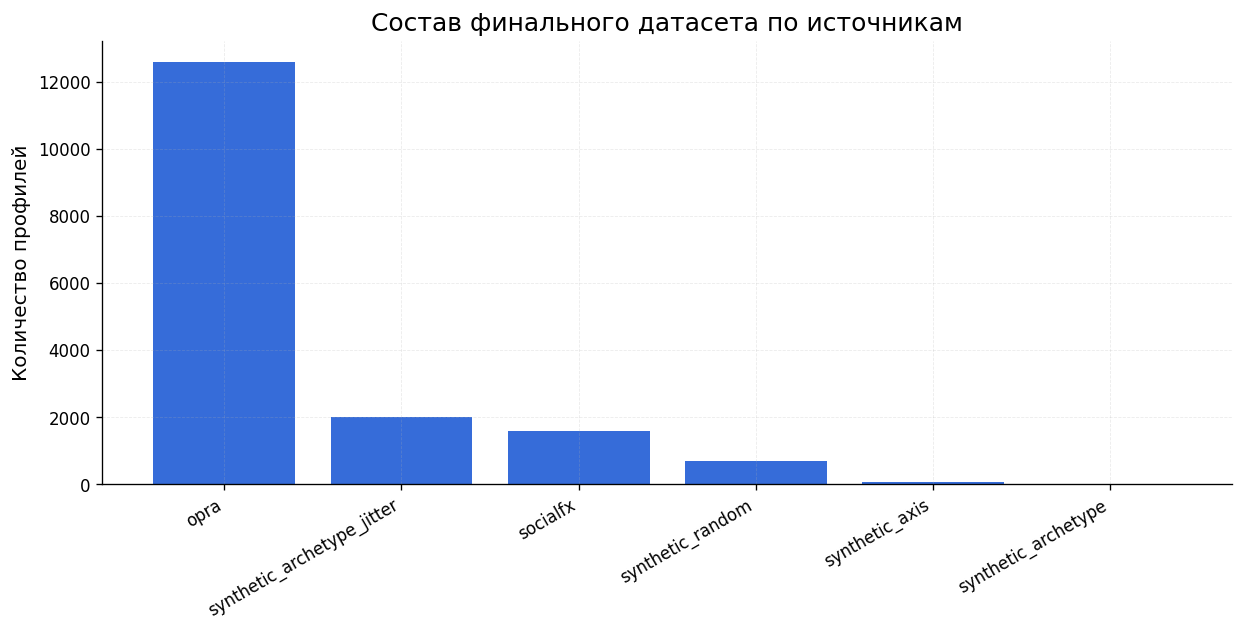

In [9]:
final_df = with_source_group(final_df)
real_unique_df = dedupe_by_curve(final_df)

if mixed_source_summary is not None:
    source_summary = mixed_source_summary.copy()
else:
    source_summary = (
        real_unique_df['source_group']
        .value_counts()
        .rename_axis('source_group')
        .reset_index(name='rows')
    )
    source_summary['is_synthetic'] = source_summary['source_group'].str.contains('synthetic')
    source_summary['share_pct'] = 100 * source_summary['rows'] / source_summary['rows'].sum()

source_summary = source_summary.sort_values('rows', ascending=False).reset_index(drop=True)
source_summary.to_csv(TABLE_DIR / 'source_summary.csv', index=False)
display(source_summary)

plt.figure(figsize=(10.5, 5.4))
x = np.arange(len(source_summary))
plt.bar(x, source_summary['rows'])
plt.xticks(x, source_summary['source_group'], rotation=30, ha='right')
plt.ylabel('Количество профилей')
plt.title('Состав финального датасета по источникам')
plt.grid(axis='y', alpha=0.25)
savefig('dataset_source_counts.png')

## 6. Средняя форма и разброс кривых эквалайзера

Для диплома полезно показать не только количество профилей, но и то, как они распределены по частотам. Ниже строятся графики `mean ± std` для OPRA, SocialFX и объединённого реального набора.

dedupe_by_curve: 12593 -> 8402
dedupe_by_curve: 12593 -> 8402
saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\opra_external_mean_std.png
saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\opra_mean_std.png
saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\socialfx_mean_std.png
saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\opra_from_final_mean_std.png
saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\final_real_merged_mean_std.png


,group,rows,mean_abs_db,mean_max_abs_db,p95_max_abs_db,max_abs_db
0,OPRA / external,8402,1.156997,5.576673,11.127593,19.925787
1,OPRA,8402,1.156997,5.576673,11.127593,19.925787
2,SocialFX,1595,0.906375,1.920107,2.407842,3.459269
3,OPRA from final,8402,1.156997,5.576673,11.127593,19.925787
4,Final real merged,9997,1.117010,4.993276,10.720697,19.925787


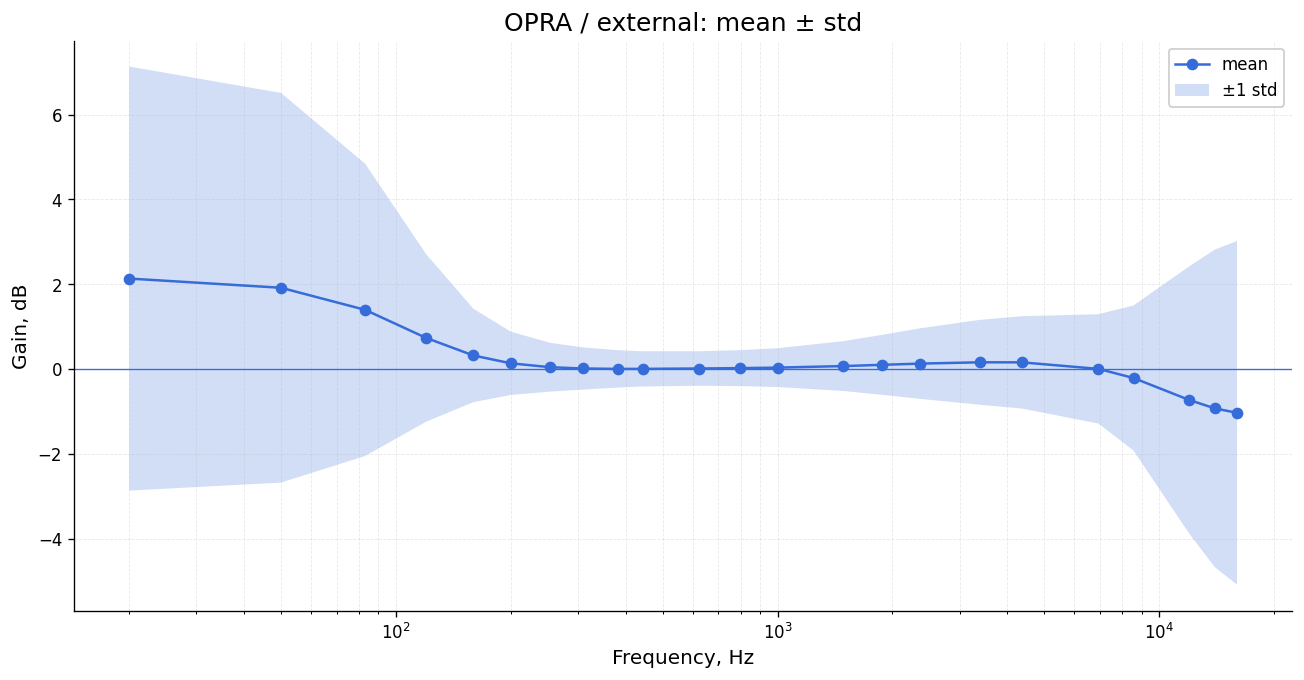

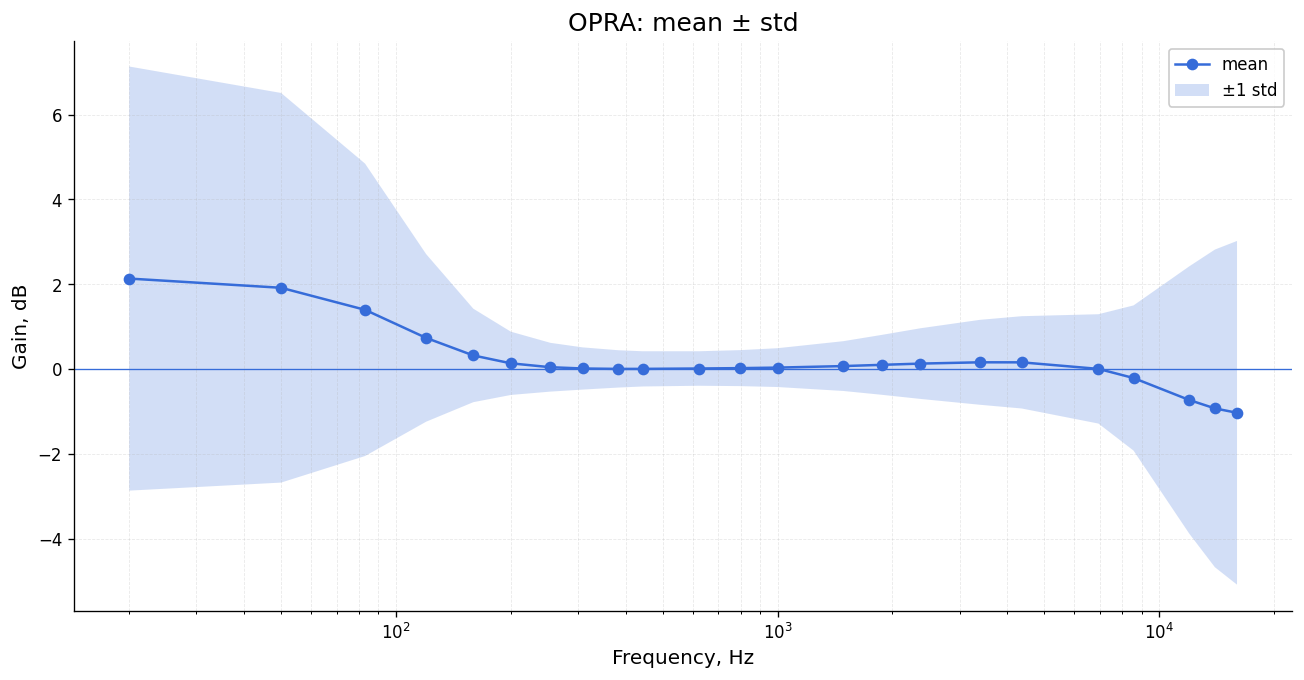

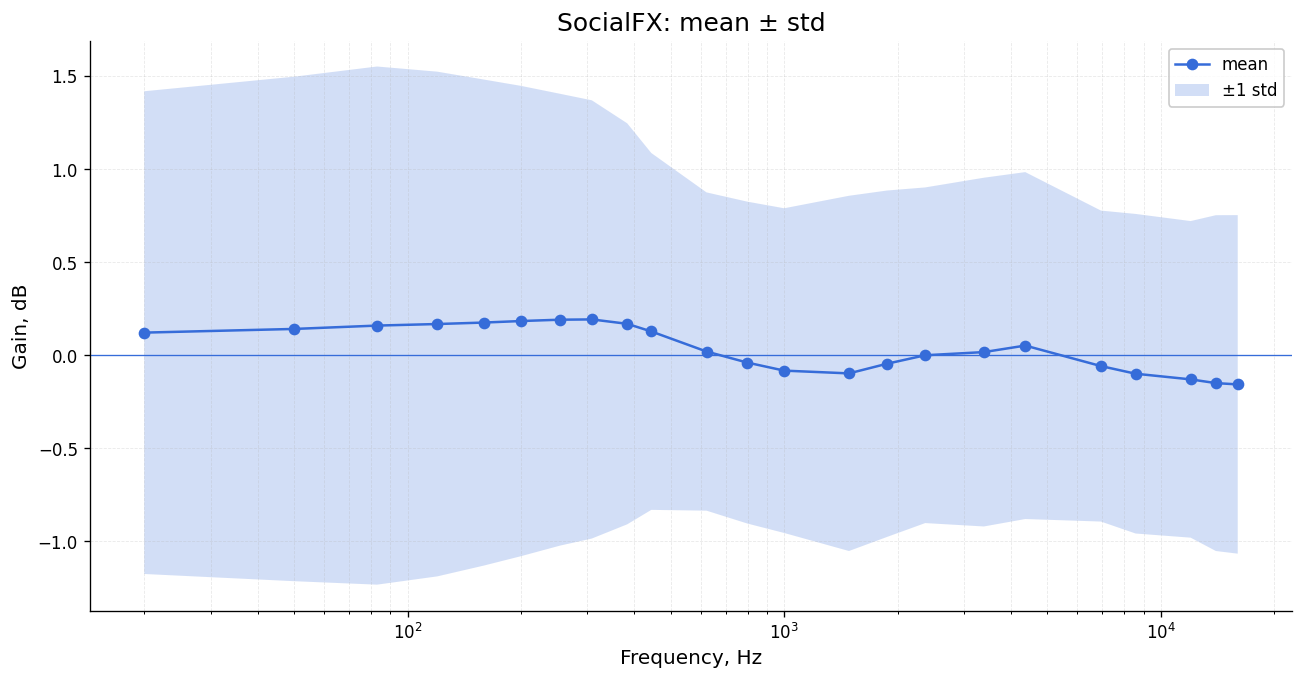

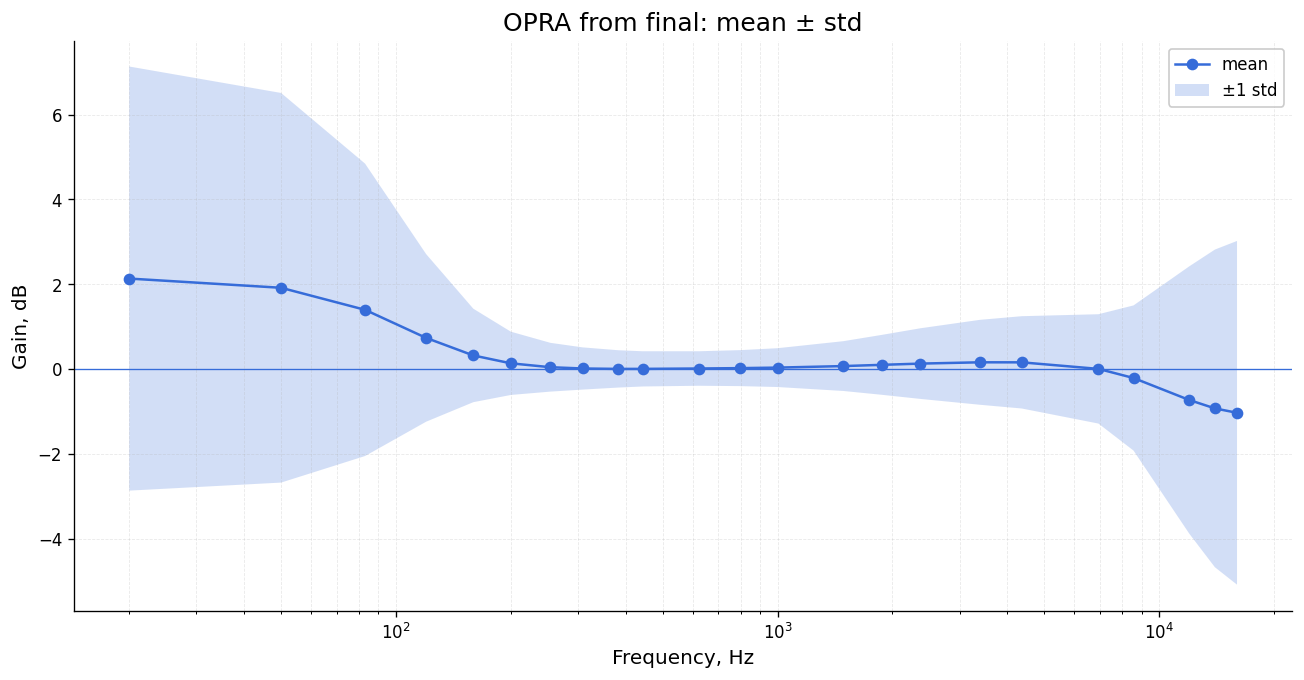

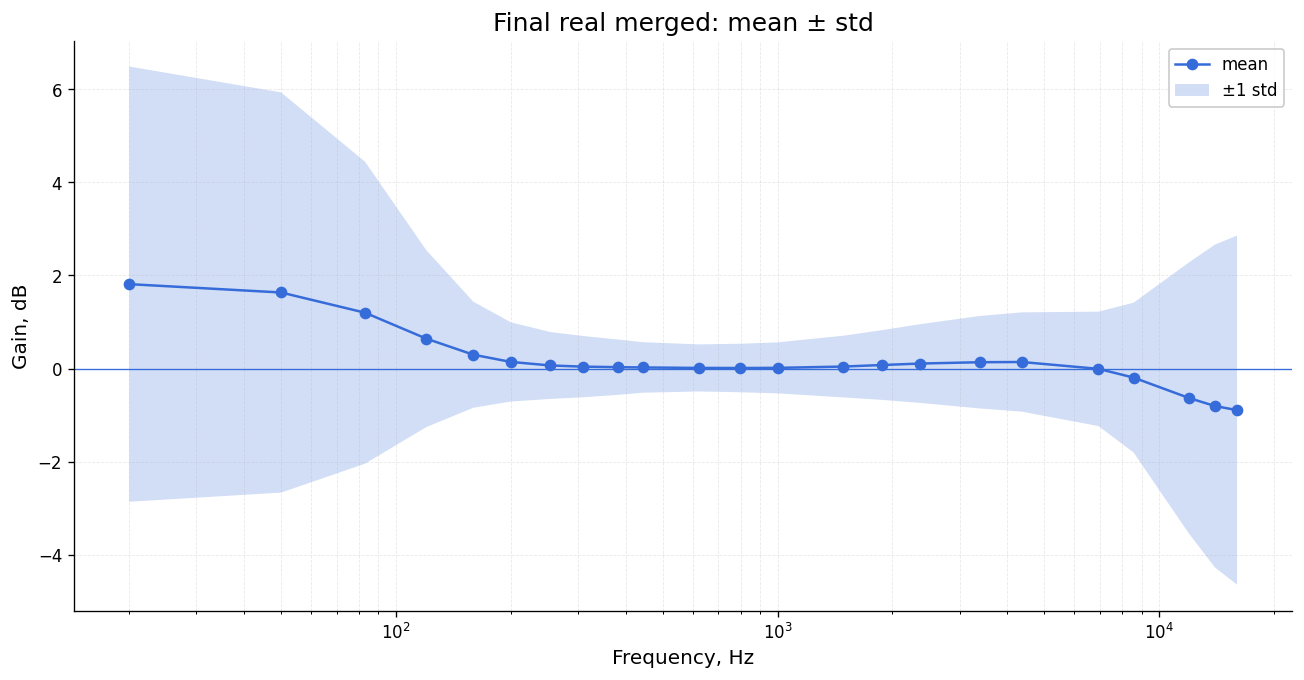

In [10]:
# Подготовка групп реальных данных.
groups: Dict[str, pd.DataFrame] = {}
if external_df is not None:
    groups['OPRA / external'] = dedupe_by_curve(with_source_group(external_df))
if opra_df is not None:
    groups['OPRA'] = dedupe_by_curve(with_source_group(opra_df))

if 'source_group' in real_unique_df.columns:
    if (real_unique_df['source_group'] == 'socialfx').any():
        groups['SocialFX'] = real_unique_df[real_unique_df['source_group'] == 'socialfx'].copy()
    if (real_unique_df['source_group'] == 'opra').any():
        groups['OPRA from final'] = real_unique_df[real_unique_df['source_group'] == 'opra'].copy()
    groups['Final real merged'] = real_unique_df[real_unique_df['source_group'].isin(['socialfx', 'opra'])].copy()

# Отрисуем mean ± std для основных групп.
curve_stats_rows = []
for name, df in groups.items():
    try:
        curves, freqs, idx = extract_curve_matrix(df)
    except Exception as e:
        print(f'[skip] {name}: {e}')
        continue
    if len(curves) == 0:
        continue
    safe_name = re.sub(r'[^a-zA-Z0-9_]+', '_', name.lower()).strip('_')
    plot_mean_std(curves, freqs, f'{name}: mean ± std', f'{safe_name}_mean_std.png')
    curve_stats_rows.append({
        'group': name,
        'rows': len(curves),
        'mean_abs_db': float(np.mean(np.abs(curves))),
        'mean_max_abs_db': float(np.mean(np.max(np.abs(curves), axis=1))),
        'p95_max_abs_db': float(np.percentile(np.max(np.abs(curves), axis=1), 95)),
        'max_abs_db': float(np.max(np.abs(curves))),
    })

curve_stats_df = pd.DataFrame(curve_stats_rows)
curve_stats_df.to_csv(TABLE_DIR / 'real_curve_stats.csv', index=False)
display(curve_stats_df)

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\real_sources_mean_curves_comparison.png


WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/mapper_v2/outputs/dataset_analysis_for_diploma/figures/real_sources_mean_curves_comparison.png')

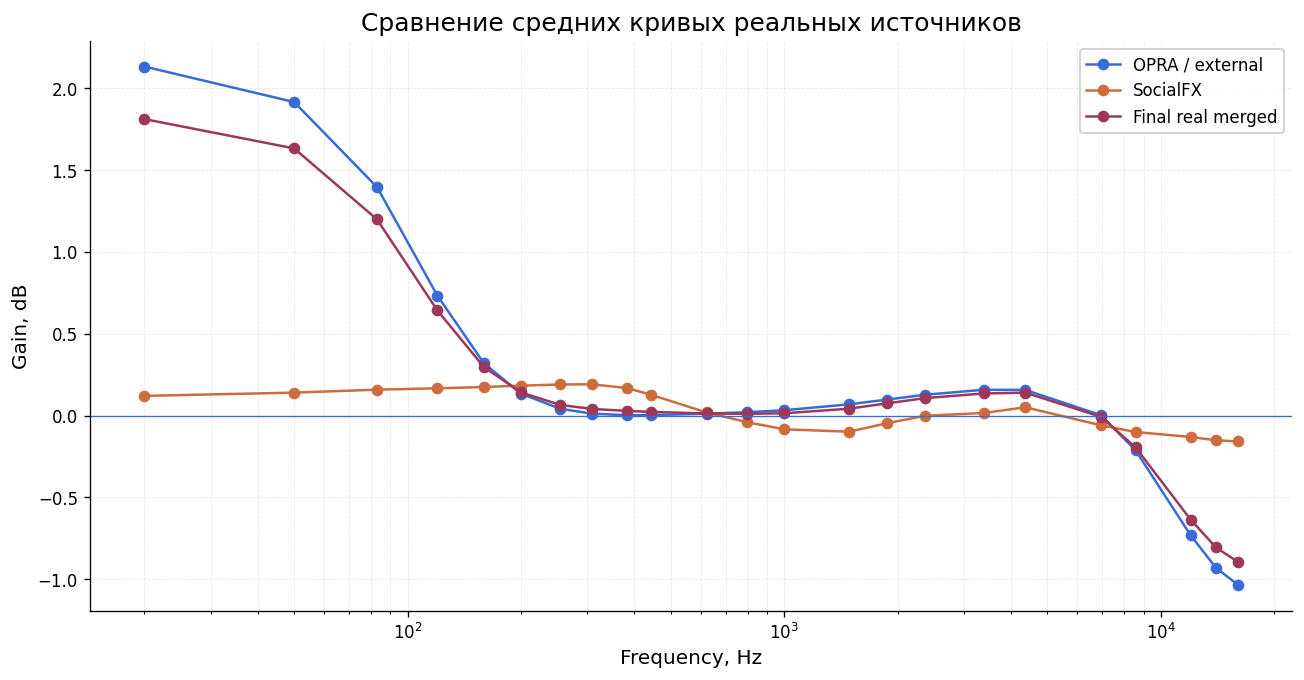

In [11]:
# Общий график сравнения средних кривых без std, чтобы не перегружать картинку.
plt.figure(figsize=(11, 5.8))
for name, df in groups.items():
    if name not in ['OPRA / external', 'SocialFX', 'Final real merged']:
        continue
    try:
        curves, freqs, idx = extract_curve_matrix(df)
        plt.plot(freqs, np.nanmean(curves, axis=0), marker='o', label=name)
    except Exception as e:
        print(f'[skip] {name}: {e}')
plt.axhline(0, linewidth=0.8)
plt.xscale('log')
plt.grid(True, which='both', alpha=0.28)
plt.xlabel('Frequency, Hz')
plt.ylabel('Gain, dB')
plt.title('Сравнение средних кривых реальных источников')
plt.legend()
savefig('real_sources_mean_curves_comparison.png')

## 7. Диапазоны кривых по источникам

Эта таблица показывает, насколько сильно профили разных источников отклоняются от нейтральной кривой. Она помогает объяснить, зачем в финальный датасет добавлялись синтетические профили: реальные источники могут иметь ограниченный разброс по отдельным направлениям, тогда как mapper должен корректно работать и в более широком contract-пространстве.

,source_group,rows,mean_abs_db,p95_abs_db,max_abs_db,mean_max_curve_abs_db
1,synthetic_archetype_jitter,2000,4.488358,12.056806,16.000000,9.967907
5,synthetic_archetype,7,4.518878,11.168966,15.045159,9.856592
3,synthetic_random,709,2.908632,8.102938,15.298779,7.661195
4,synthetic_axis,64,1.206174,5.348290,12.605610,5.483063
0,opra,12593,1.097051,5.549853,19.925787,5.302817
2,socialfx,1595,0.906375,1.877683,3.459269,1.920107


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\target_range_mean_max_abs_by_source.png
saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\target_range_p95_abs_by_source.png


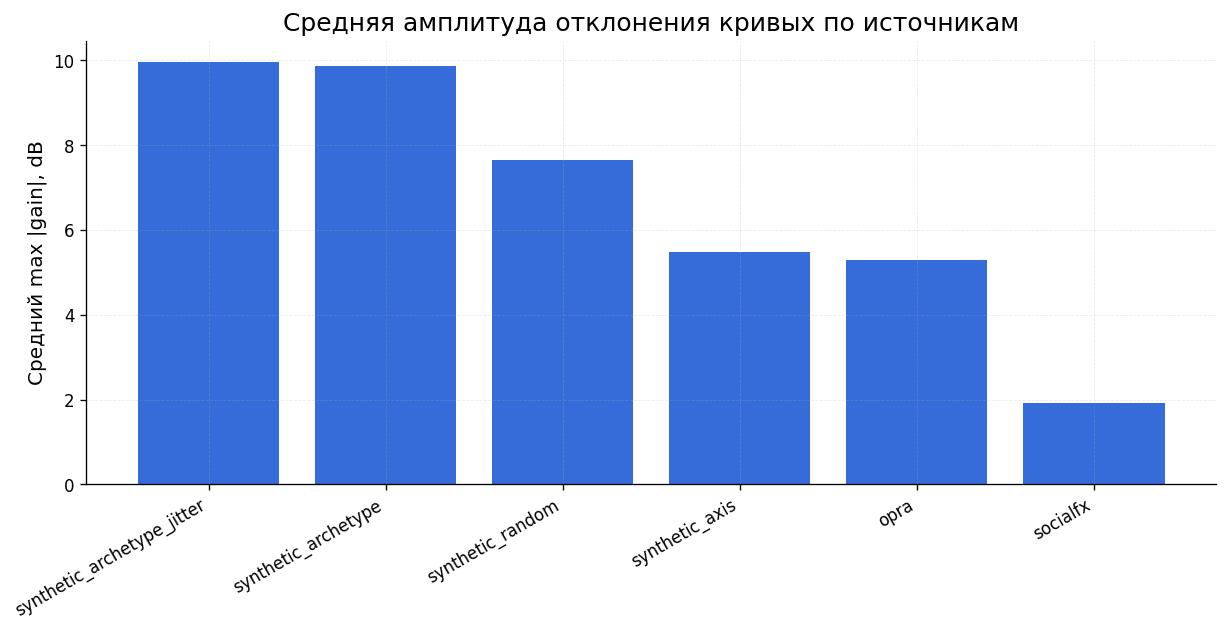

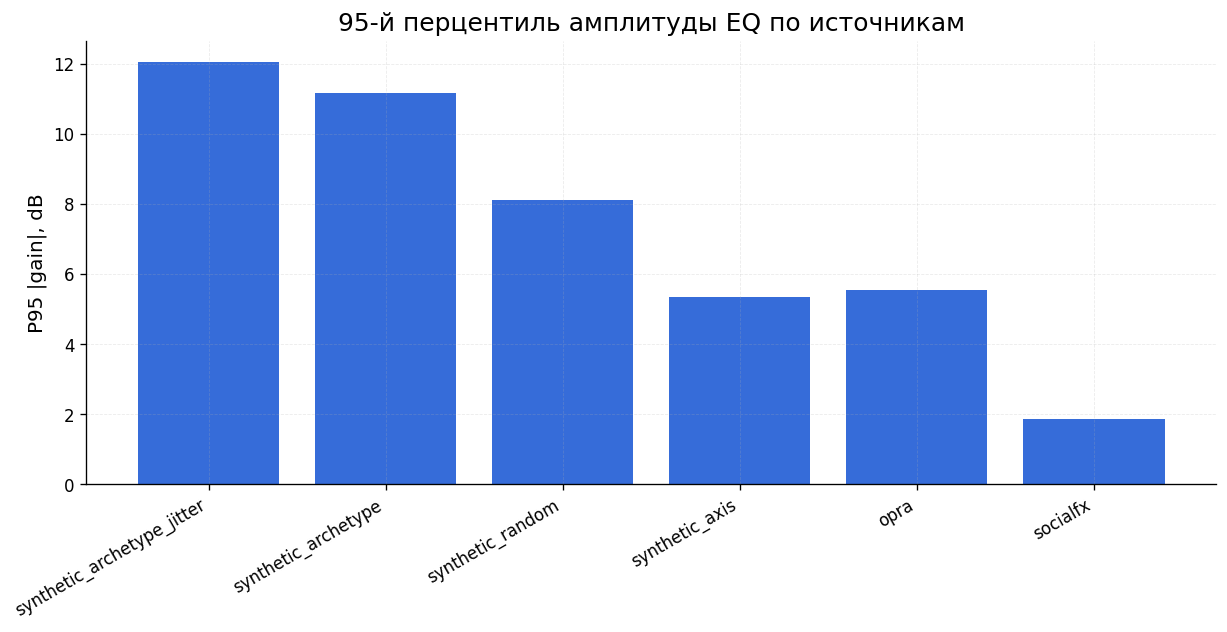

In [12]:
if target_range_by_source is not None:
    tr = target_range_by_source.copy().sort_values('mean_max_curve_abs_db', ascending=False)
else:
    tr = curve_stats_df.rename(columns={'mean_max_abs_db': 'mean_max_curve_abs_db', 'group': 'source_group'})

tr.to_csv(TABLE_DIR / 'target_range_by_source.csv', index=False)
display(tr)

if {'source_group', 'mean_max_curve_abs_db'}.issubset(tr.columns):
    plt.figure(figsize=(10.5, 5.4))
    x = np.arange(len(tr))
    plt.bar(x, tr['mean_max_curve_abs_db'])
    plt.xticks(x, tr['source_group'], rotation=30, ha='right')
    plt.ylabel('Средний max |gain|, dB')
    plt.title('Средняя амплитуда отклонения кривых по источникам')
    plt.grid(axis='y', alpha=0.25)
    savefig('target_range_mean_max_abs_by_source.png')

if {'source_group', 'p95_abs_db'}.issubset(tr.columns):
    plt.figure(figsize=(10.5, 5.4))
    x = np.arange(len(tr))
    plt.bar(x, tr['p95_abs_db'])
    plt.xticks(x, tr['source_group'], rotation=30, ha='right')
    plt.ylabel('P95 |gain|, dB')
    plt.title('95-й перцентиль амплитуды EQ по источникам')
    plt.grid(axis='y', alpha=0.25)
    savefig('target_range_p95_abs_by_source.png')

## 8. Анализ 8D/contract-признаков

Здесь анализируется, насколько разные источники покрывают координаты weighted 8D / contract-пространства. Для mapper это важно, потому что модель должна не только восстанавливать кривую, но и сохранять управляемость каждой оси.

In [13]:
def get_feature_columns(df: pd.DataFrame, prefix_candidates: Sequence[str]) -> List[str]:
    for prefix in prefix_candidates:
        cols = [f'{prefix}{f}' for f in FEATURES_8D if f'{prefix}{f}' in df.columns]
        if len(cols) == len(FEATURES_8D):
            return cols
    return []

scaled_cols = get_feature_columns(real_unique_df, ['z8_scaled_', 'z8n_', 'z8_'])
raw_cols = get_feature_columns(real_unique_df, ['z8_raw_', 'z8_'])
print('scaled_cols:', scaled_cols)
print('raw_cols:', raw_cols)

axis_stats_rows = []
if scaled_cols:
    for group, gdf in real_unique_df.groupby('source_group'):
        vals = gdf[scaled_cols].apply(pd.to_numeric, errors='coerce')
        for feature, col in zip(FEATURES_8D, scaled_cols):
            s = vals[col].dropna()
            if len(s) == 0:
                continue
            axis_stats_rows.append({
                'source_group': group,
                'feature': feature,
                'rows': len(s),
                'mean': s.mean(),
                'std': s.std(),
                'min': s.min(),
                'p05': s.quantile(0.05),
                'p50': s.quantile(0.50),
                'p95': s.quantile(0.95),
                'max': s.max(),
                'pct_at_minus_2': float((s <= -1.999).mean() * 100),
                'pct_at_plus_2': float((s >= 1.999).mean() * 100),
            })

axis_stats = pd.DataFrame(axis_stats_rows)
axis_stats.to_csv(TABLE_DIR / 'axis_coverage_by_source.csv', index=False)
display(axis_stats.head(20))

scaled_cols: ['z8_scaled_sub_bass', 'z8_scaled_bass', 'z8_scaled_lowmid', 'z8_scaled_warmth', 'z8_scaled_presence', 'z8_scaled_clarity', 'z8_scaled_air', 'z8_scaled_brightness']
raw_cols: ['z8_raw_sub_bass', 'z8_raw_bass', 'z8_raw_lowmid', 'z8_raw_warmth', 'z8_raw_presence', 'z8_raw_clarity', 'z8_raw_air', 'z8_raw_brightness']


,source_group,feature,rows,mean,std,min,p05,p50,p95,max,pct_at_minus_2,pct_at_plus_2
0,opra,sub_bass,8402,0.100649,1.216653,-2.000000,-2.000000,0.057013,2.000000,2.000000,5.308260,7.129255
1,opra,bass,8402,0.085765,1.197613,-2.000000,-2.000000,0.000004,2.000000,2.000000,5.510593,6.998334
2,opra,lowmid,8402,0.079901,1.018454,-2.000000,-1.641697,-0.000647,2.000000,2.000000,3.034992,5.534397
3,opra,warmth,8402,0.097736,0.804372,-2.000000,-1.036717,0.005729,2.000000,2.000000,1.844799,5.260652
4,opra,presence,8402,0.026235,0.790014,-2.000000,-1.197919,0.017931,2.000000,2.000000,1.356820,5.165437
5,opra,clarity,8402,0.006474,1.177100,-2.000000,-2.000000,0.027870,2.000000,2.000000,6.462747,6.034278
6,opra,air,8402,-0.018017,1.181416,-2.000000,-2.000000,0.029546,1.971108,2.000000,7.283980,4.665556
7,opra,brightness,8402,0.008729,1.166244,-2.000000,-2.000000,0.006480,2.000000,2.000000,6.117591,6.010474
8,socialfx,sub_bass,1595,-0.405536,0.463581,-1.370828,-1.125909,-0.373722,0.254189,0.470408,0.000000,0.000000
9,socialfx,bass,1595,-0.296002,1.056806,-2.000000,-1.906782,-0.158079,1.078228,1.302541,2.068966,0.000000


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\axis_boxplot_socialfx.png
saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\axis_boxplot_opra.png
saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\axis_coverage_heatmap_p95_p05.png


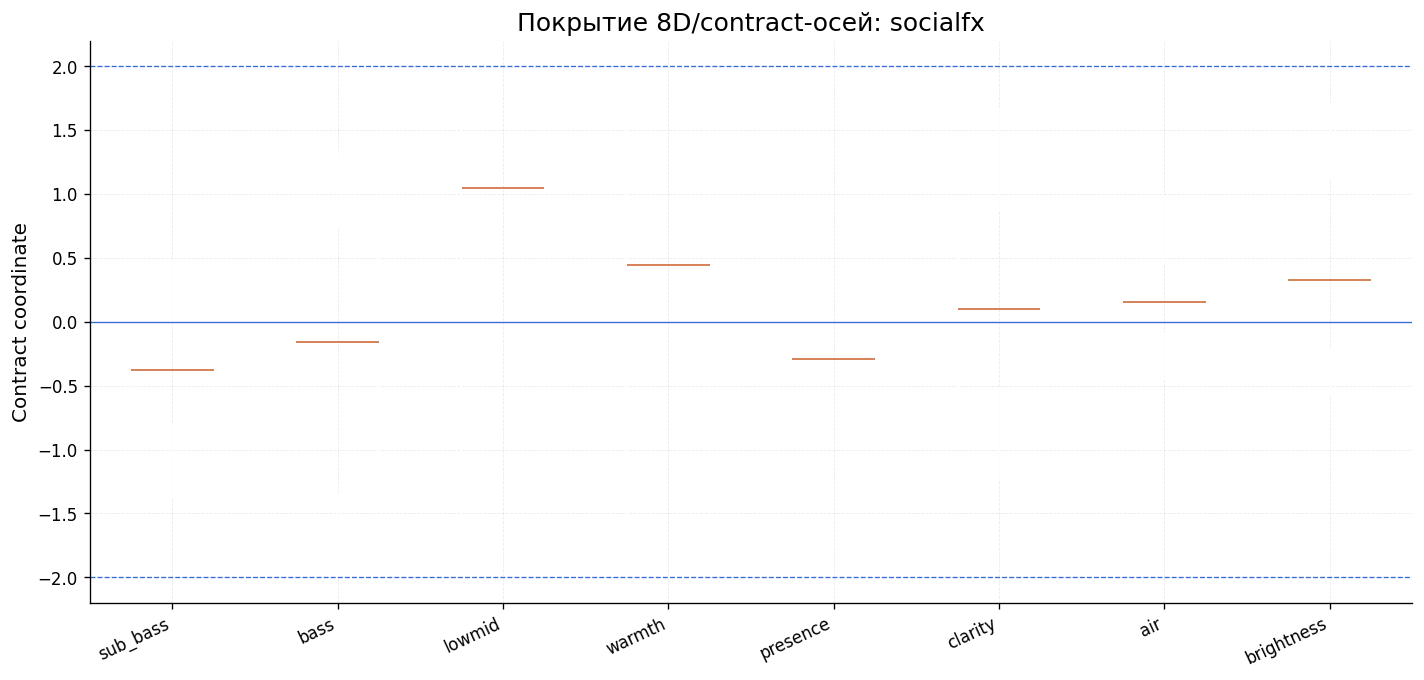

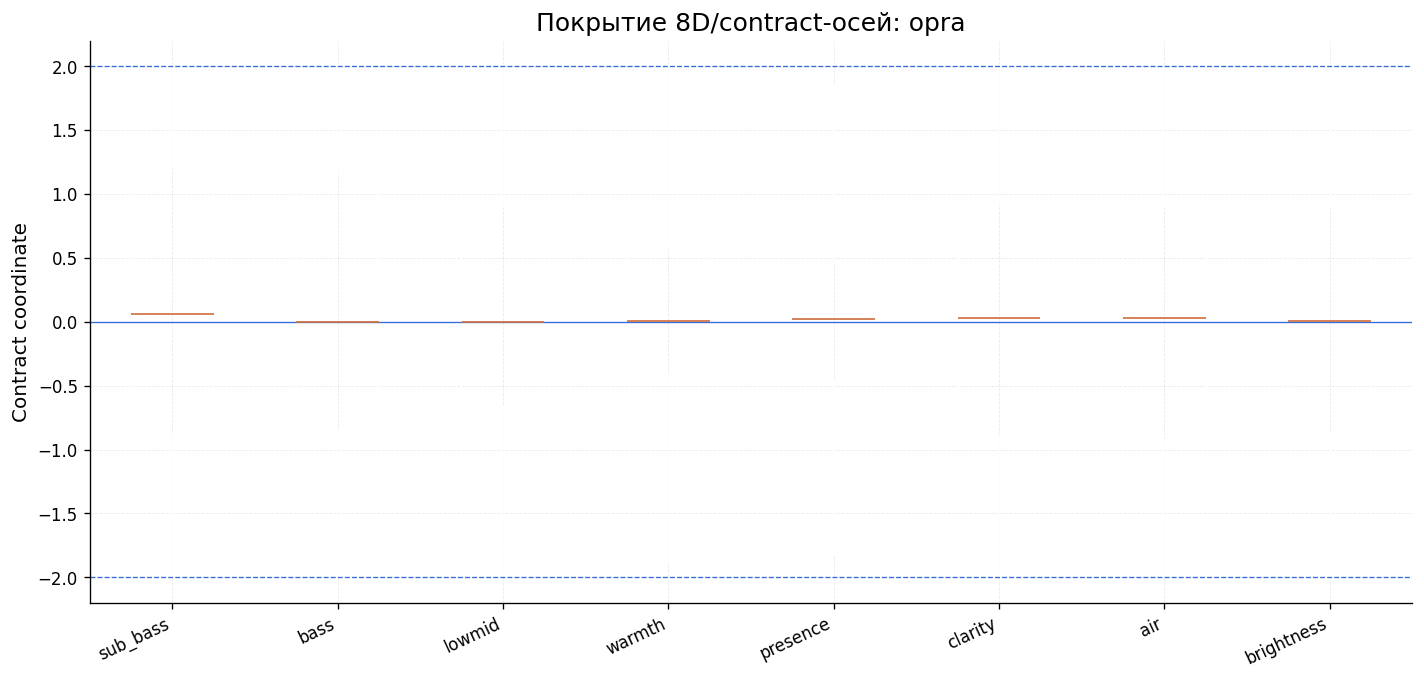

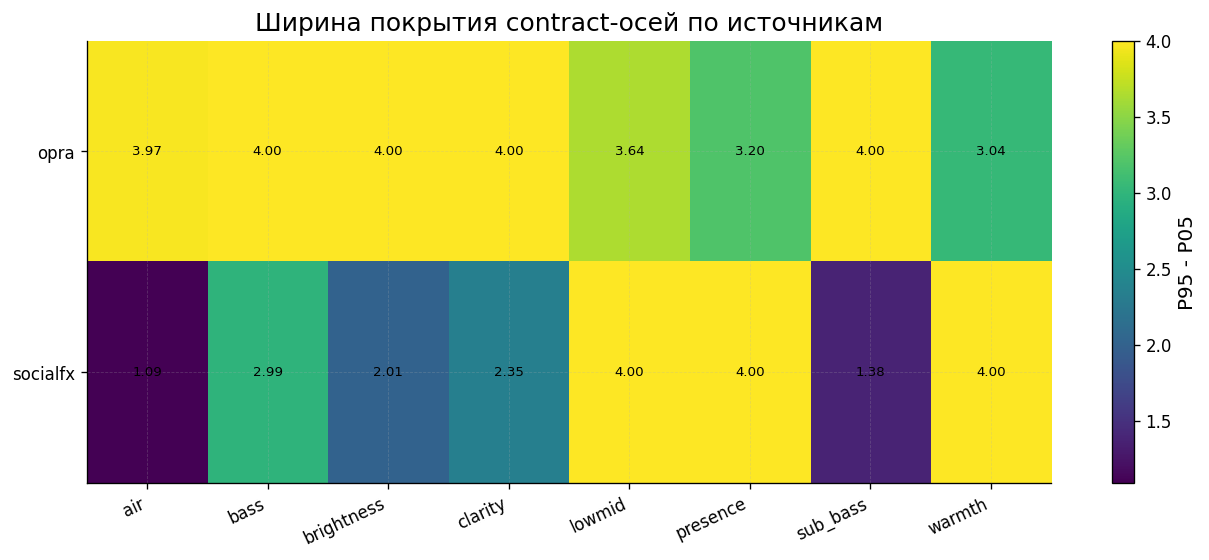

In [14]:
# Boxplot по 8D/contract координатам для реальных источников.
if scaled_cols:
    for group in ['socialfx', 'opra']:
        gdf = real_unique_df[real_unique_df['source_group'] == group]
        if len(gdf) == 0:
            continue
        vals = gdf[scaled_cols].apply(pd.to_numeric, errors='coerce')
        plt.figure(figsize=(12, 5.8))
        plt.boxplot([vals[c].dropna().values for c in scaled_cols], labels=FEATURES_8D, showfliers=False)
        plt.axhline(0, linewidth=0.8)
        plt.axhline(2, linestyle='--', linewidth=0.8)
        plt.axhline(-2, linestyle='--', linewidth=0.8)
        plt.ylabel('Contract coordinate')
        plt.title(f'Покрытие 8D/contract-осей: {group}')
        plt.xticks(rotation=25, ha='right')
        plt.grid(axis='y', alpha=0.25)
        savefig(f'axis_boxplot_{group}.png')

    # Heatmap ширины интервала p95-p05 по источникам.
    if not axis_stats.empty:
        width = axis_stats.copy()
        width['p95_p05_width'] = width['p95'] - width['p05']
        pivot = width.pivot_table(index='source_group', columns='feature', values='p95_p05_width', aggfunc='mean')
        plt.figure(figsize=(11, 4.8))
        im = plt.imshow(pivot.values, aspect='auto')
        plt.colorbar(im, label='P95 - P05')
        plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=25, ha='right')
        plt.yticks(np.arange(len(pivot.index)), pivot.index)
        plt.title('Ширина покрытия contract-осей по источникам')
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.iloc[i, j]
                if np.isfinite(val):
                    plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
        savefig('axis_coverage_heatmap_p95_p05.png')

## 9. Синтетические профили и их роль

Синтетические профили не подменяют реальные пользовательские данные. Их задача — контролируемо закрыть те направления 8D/contract-пространства, которые слабо представлены в реальных наборах. Это особенно важно для осей, по которым mapper должен быть управляемым, но в реальных профилях недостаточно примеров сильного положительного или отрицательного смещения.

В проекте использовались несколько групп синтетических данных:

- `synthetic_axis` — профили, меняющие отдельные оси, полезны для проверки локальной управляемости;
- `synthetic_archetype` — интерпретируемые архетипы звучания;
- `synthetic_archetype_jitter` — вариации архетипов, повышающие устойчивость модели;
- `synthetic_random` — случайные допустимые комбинации осей, расширяющие покрытие пространства.

,source_group,rows,mean_abs_db,mean_max_abs_db,p95_max_abs_db,max_abs_db
0,synthetic_archetype_jitter,2000,4.488358,9.967907,15.946220,16.000000
1,synthetic_archetype,7,4.518878,9.856592,15.009153,15.045159
2,synthetic_random,709,2.908632,7.661195,11.938205,15.298779
3,synthetic_axis,64,1.206174,5.483063,11.174770,12.605610
4,opra,12593,1.097051,5.302817,10.574081,19.925787
5,socialfx,1595,0.906375,1.920107,2.407842,3.459269


,source_group,rows,mean_abs_z,mean_max_abs_z,p95_max_abs_z,max_abs_z
0,synthetic_archetype_jitter,2000,0.593258,1.286709,1.996982,2.000000
1,synthetic_axis,64,0.156250,1.250000,2.000000,2.000000
2,synthetic_archetype,7,0.579464,1.242857,1.620000,1.650000
3,synthetic_random,709,0.538640,1.220906,1.939532,2.000000
4,opra,12593,0.232876,0.657055,1.399219,2.000000
5,socialfx,1595,0.194742,0.400917,0.517023,0.561752


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\synthetic_contract_z_amplitude.png
saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\synthetic_curve_amplitude.png


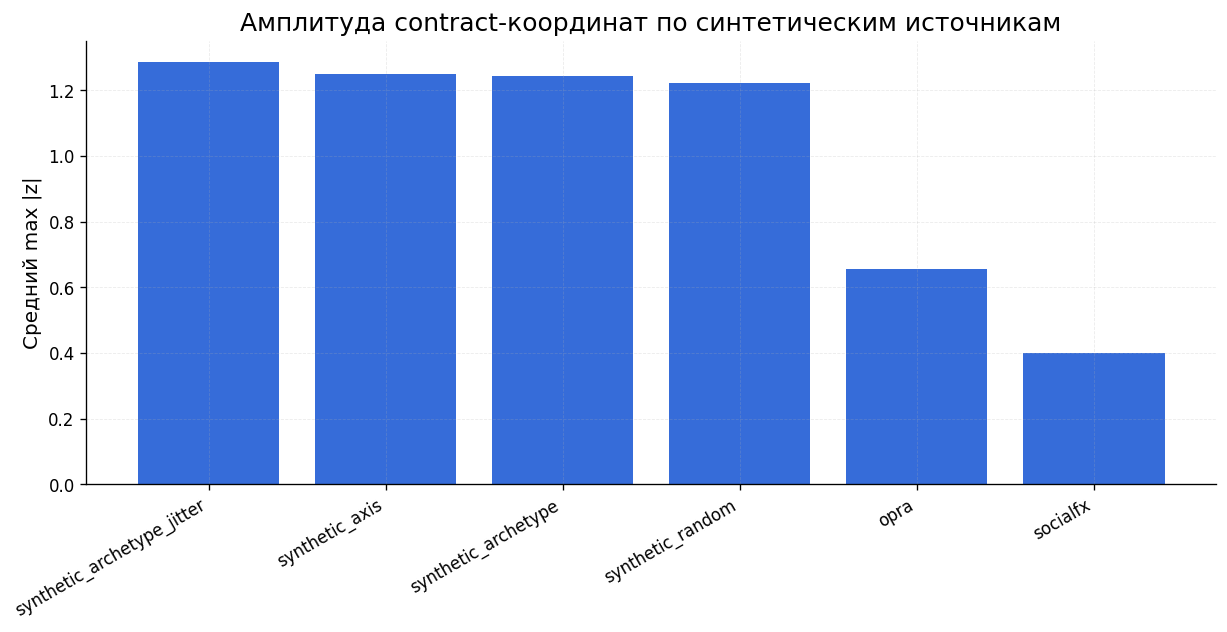

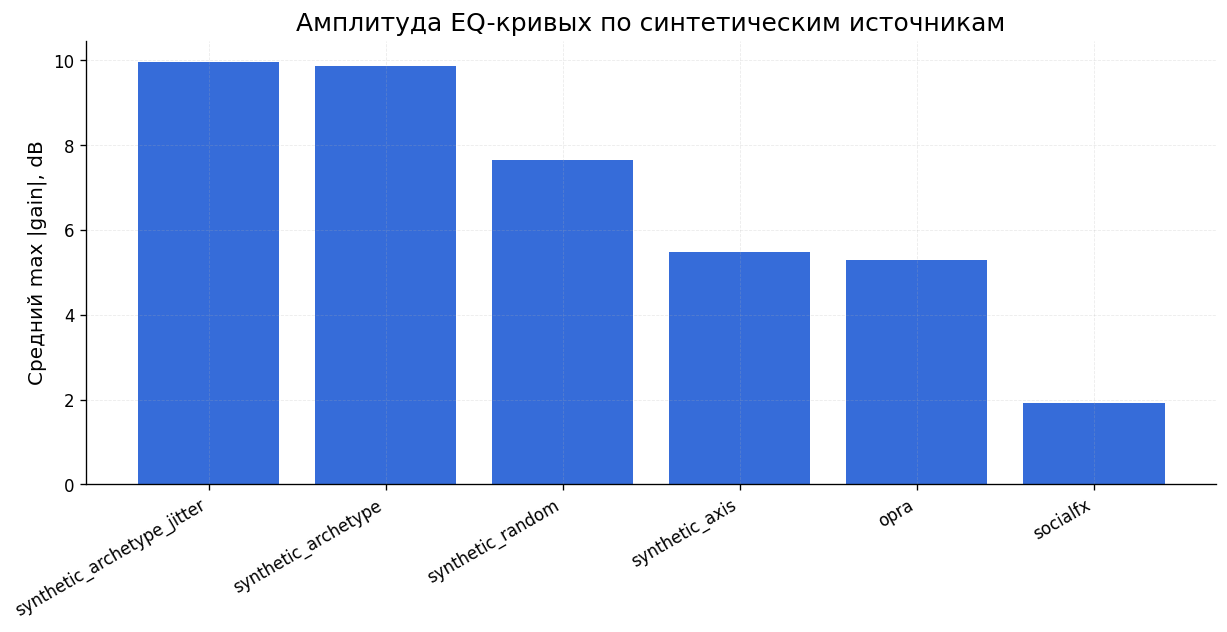

In [15]:
# Таблицы по синтетике, если они доступны.
if source_curve_stats is not None:
    display(source_curve_stats)
    source_curve_stats.to_csv(TABLE_DIR / 'source_curve_stats.csv', index=False)

if source_z_stats is not None:
    display(source_z_stats)
    source_z_stats.to_csv(TABLE_DIR / 'source_z_contract_stats.csv', index=False)

if source_z_stats is not None and {'source_group', 'mean_max_abs_z'}.issubset(source_z_stats.columns):
    zstats = source_z_stats.sort_values('mean_max_abs_z', ascending=False)
    plt.figure(figsize=(10.5, 5.4))
    x = np.arange(len(zstats))
    plt.bar(x, zstats['mean_max_abs_z'])
    plt.xticks(x, zstats['source_group'], rotation=30, ha='right')
    plt.ylabel('Средний max |z|')
    plt.title('Амплитуда contract-координат по синтетическим источникам')
    plt.grid(axis='y', alpha=0.25)
    savefig('synthetic_contract_z_amplitude.png')

if source_curve_stats is not None and {'source_group', 'mean_max_abs_db'}.issubset(source_curve_stats.columns):
    cstats = source_curve_stats.sort_values('mean_max_abs_db', ascending=False)
    plt.figure(figsize=(10.5, 5.4))
    x = np.arange(len(cstats))
    plt.bar(x, cstats['mean_max_abs_db'])
    plt.xticks(x, cstats['source_group'], rotation=30, ha='right')
    plt.ylabel('Средний max |gain|, dB')
    plt.title('Амплитуда EQ-кривых по синтетическим источникам')
    plt.grid(axis='y', alpha=0.25)
    savefig('synthetic_curve_amplitude.png')

## 10. Contract-шкала и допустимые raw dB-диапазоны

Разные оси weighted 8D имеют разные естественные диапазоны изменения в dB. Поэтому одинаковое значение во внутренней шкале означает сопоставимую силу пользовательского намерения, но не одинаковое усиление в децибелах.

,feature,extreme_raw_db_for_abs_z_2,raw_db_per_1_z_unit
0,sub_bass,16.0,8.0
1,bass,14.0,7.0
2,lowmid,6.0,3.0
3,warmth,6.0,3.0
4,presence,5.0,2.5
5,clarity,7.0,3.5
6,air,12.0,6.0
7,brightness,8.0,4.0


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\contract_raw_db_per_z_unit.png


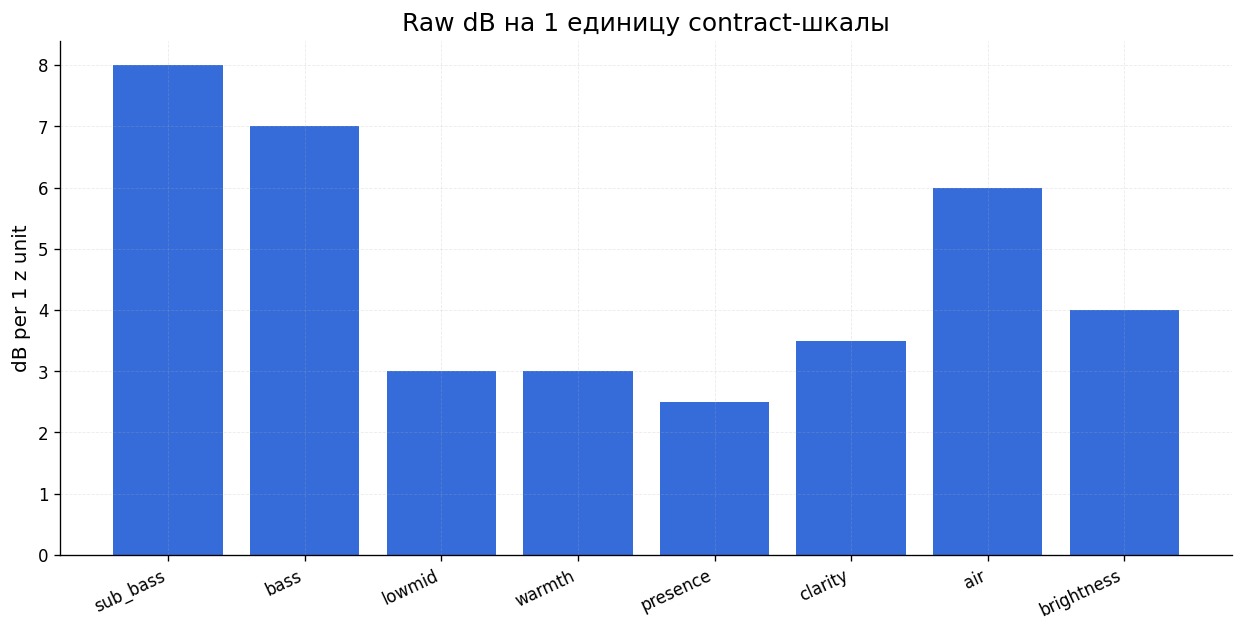

In [16]:
scale_table = None
if contract_extreme_db is not None:
    scale_table = contract_extreme_db.copy()
elif feature_scale_normalizer is not None:
    scale_table = feature_scale_normalizer.copy()

if scale_table is not None:
    display(scale_table)
    scale_table.to_csv(TABLE_DIR / 'contract_scale_table.csv', index=False)

    if 'raw_db_per_1_z_unit' in scale_table.columns:
        val_col = 'raw_db_per_1_z_unit'
        title = 'Raw dB на 1 единицу contract-шкалы'
        ylabel = 'dB per 1 z unit'
    elif 'scale_raw_per_z_unit' in scale_table.columns:
        val_col = 'scale_raw_per_z_unit'
        title = 'Raw dB на 1 единицу contract-шкалы'
        ylabel = 'dB per 1 z unit'
    else:
        val_col = None

    if val_col is not None:
        plt.figure(figsize=(10.5, 5.4))
        x = np.arange(len(scale_table))
        labels = scale_table['feature'] if 'feature' in scale_table.columns else np.arange(len(scale_table))
        plt.bar(x, scale_table[val_col])
        plt.xticks(x, labels, rotation=25, ha='right')
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(axis='y', alpha=0.25)
        savefig('contract_raw_db_per_z_unit.png')
else:
    print('Не найдена таблица contract-шкалы.')

## 11. Связь состава данных с качеством mapper

Если доступны таблицы оценки mapper по источникам, notebook строит графики, показывающие, на каких группах данных модель восстанавливает кривую лучше или хуже. Это помогает объяснить, что финальный датасет нужен не только для уменьшения средней ошибки, но и для проверки модели на разных типах профилей.

,model,source_group,rows,mse,mae,mean_target_max_abs_db,mean_pred_max_abs_db,mean_max_abs_error_db
0,Model A contract MLP baseline,synthetic_archetype,1,0.002857,0.040216,5.502404,5.448468,0.150519
1,Model A contract MLP baseline,opra,1890,0.011397,0.029725,5.362224,5.354102,0.095600
2,Model A contract MLP baseline,synthetic_axis,10,0.039291,0.134532,4.120597,4.251944,0.415729
3,Model A contract MLP baseline,socialfx,239,0.040946,0.135713,1.917016,1.837449,0.452533
4,Model A contract MLP baseline,synthetic_archetype_jitter,300,0.049055,0.086996,9.761045,9.767865,0.246094
5,Model A contract MLP baseline,synthetic_random,106,0.154337,0.219859,7.755820,7.728505,0.720627
6,Model B contract controllable MLP,synthetic_archetype,1,0.006122,0.063292,5.502404,5.636269,0.144280
7,Model B contract controllable MLP,opra,1890,0.014426,0.038455,5.362224,5.409825,0.130339
8,Model B contract controllable MLP,socialfx,239,0.043119,0.140459,1.917016,1.834548,0.463909
9,Model B contract controllable MLP,synthetic_axis,10,0.045510,0.152231,4.120597,4.295346,0.432202


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\dataset_analysis_for_diploma\figures\model_b_mse_by_source.png


,model,test_mse,test_mae,mean_basis_alignment,mean_target_off_ratio,mean_sign_consistency,mean_monotonicity_score,mean_scale_gain_z2_minus_z0,mean_extreme_peak_abs_db,mean_extreme_target_abs_db,...,test_eval_loss,test_eval_mse,test_eval_smooth,test_eval_ctrl,test_eval_residual_penalty,device,parameters,epochs,train_seconds,seconds_per_epoch
0,Model B contract controllable MLP,0.025822,0.063468,0.989110,10.122637,0.953125,1.0,5.846598,7.875495,5.859747,...,0.025829,0.025822,0.810859,0.002023,0.000000,cpu,27415,250,480.740720,1.922963
1,Model C contract basis residual hybrid,0.026247,0.060101,0.984369,10.598014,0.953125,1.0,5.808272,7.850563,5.818447,...,0.059859,0.026247,0.807219,0.001979,33.606849,cpu,27415,250,527.758028,2.111032
2,Model A contract MLP baseline,0.027726,0.061228,0.988365,10.366776,0.953125,1.0,5.860902,7.897709,5.866875,...,0.027726,0.027726,0.808989,0.000000,0.000000,cpu,27415,250,82.214884,0.328860


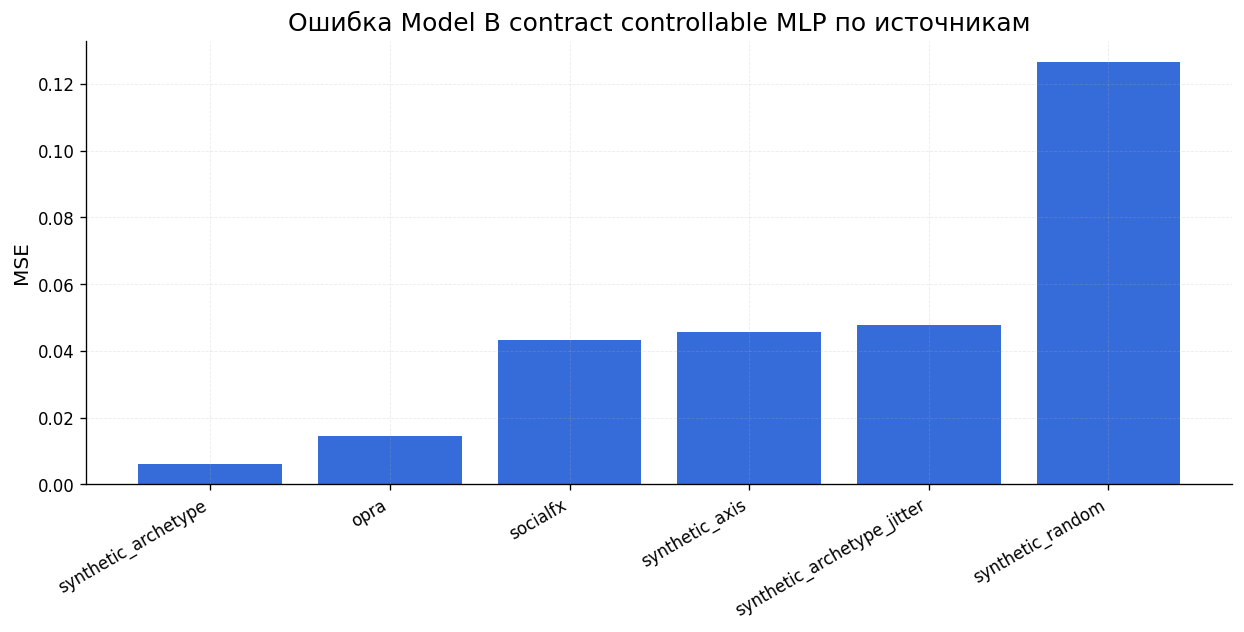

In [17]:
if contract_eval is not None:
    contract_eval.to_csv(TABLE_DIR / 'contract_eval_by_source.csv', index=False)
    display(contract_eval.head(20))

    # График MSE по источникам для Model B, так как она выбрана финальной.
    model_b_mask = contract_eval['model'].astype(str).str.contains('Model B', case=False, na=False)
    model_b_eval = contract_eval[model_b_mask].sort_values('mse')
    if len(model_b_eval):
        plt.figure(figsize=(10.5, 5.4))
        x = np.arange(len(model_b_eval))
        plt.bar(x, model_b_eval['mse'])
        plt.xticks(x, model_b_eval['source_group'], rotation=30, ha='right')
        plt.ylabel('MSE')
        plt.title('Ошибка Model B contract controllable MLP по источникам')
        plt.grid(axis='y', alpha=0.25)
        savefig('model_b_mse_by_source.png')

if contract_summary_df is not None:
    contract_summary_df.to_csv(TABLE_DIR / 'contract_model_summary.csv', index=False)
    display(contract_summary_df)

## 12. Выводы для текста диплома

Эта ячейка формирует короткий `dataset_analysis_summary.md`, который можно использовать как основу для фрагмента главы.

In [18]:
summary_lines = []
summary_lines.append('# Анализ датасетов mapper-модели')
summary_lines.append('')
summary_lines.append('## Состав данных')
if source_summary is not None:
    for _, row in source_summary.iterrows():
        name = row.get('source_group', 'unknown')
        rows = int(row.get('rows', 0)) if pd.notna(row.get('rows', np.nan)) else 0
        share = row.get('share_pct', np.nan)
        if pd.notna(share):
            summary_lines.append(f'- {name}: {rows} профилей ({share:.2f}%).')
        else:
            summary_lines.append(f'- {name}: {rows} профилей.')
summary_lines.append('')
summary_lines.append('## Основной вывод')
summary_lines.append(
    'Качество mapper зависит не только от архитектуры модели, но и от покрытия обучающих данных. '
    'Реальные источники SocialFX и OPRA дают базовые кривые эквалайзера, однако синтетические группы '
    'используются для контролируемого покрытия отдельных направлений 8D/contract-пространства.'
)
summary_lines.append('')
summary_lines.append('## Роль синтетических профилей')
summary_lines.append(
    'Синтетические профили добавляются не как замена реальных данных, а как инженерный способ проверить и усилить '
    'управляемость mapper по отдельным осям. Группы synthetic_axis, synthetic_archetype, '
    'synthetic_archetype_jitter и synthetic_random закрывают разные сценарии: изменение одной оси, '
    'типовые профили звучания, устойчивость к вариациям и комбинированные смещения.'
)
summary_lines.append('')
summary_lines.append('## Созданные графики')
for p in sorted(FIG_DIR.glob('*.png')):
    summary_lines.append(f'- `{p.relative_to(PROJECT_ROOT)}`')
summary_text = '\n'.join(summary_lines)
summary_path = ANALYSIS_DIR / 'dataset_analysis_summary.md'
summary_path.write_text(summary_text, encoding='utf-8')
print(summary_text)
print('\nsaved:', summary_path)

# Анализ датасетов mapper-модели

## Состав данных
- opra: 12593 профилей (74.22%).
- synthetic_archetype_jitter: 2000 профилей (11.79%).
- socialfx: 1595 профилей (9.40%).
- synthetic_random: 709 профилей (4.18%).
- synthetic_axis: 64 профилей (0.38%).
- synthetic_archetype: 7 профилей (0.04%).

## Основной вывод
Качество mapper зависит не только от архитектуры модели, но и от покрытия обучающих данных. Реальные источники SocialFX и OPRA дают базовые кривые эквалайзера, однако синтетические группы используются для контролируемого покрытия отдельных направлений 8D/contract-пространства.

## Роль синтетических профилей
Синтетические профили добавляются не как замена реальных данных, а как инженерный способ проверить и усилить управляемость mapper по отдельным осям. Группы synthetic_axis, synthetic_archetype, synthetic_archetype_jitter и synthetic_random закрывают разные сценарии: изменение одной оси, типовые профили звучания, устойчивость к вариациям и комбинированные смещения.

## Созд

## 13. Список созданных файлов

In [ ]:
print('CSV tables:')
for p in sorted(TABLE_DIR.glob('*.csv')):
    print('-', p.relative_to(PROJECT_ROOT))
print('\nFigures:')
for p in sorted(FIG_DIR.glob('*.png')):
    print('-', p.relative_to(PROJECT_ROOT))
print('\nSummary:')
print('-', (ANALYSIS_DIR / 'dataset_analysis_summary.md').relative_to(PROJECT_ROOT))